In [3]:
import os
import requests
def load(url):
    filename = os.path.basename(url)
    response = requests.get(url)
    with open(filename, "wb") as f:
        f.write(response.content)
    df = pd.read_csv(filename)
    display(df.head())
    return df

In [4]:
import numpy as np
import pandas as pd
data = load("https://files.0xarchit.is-a.dev/datasets/equipment_anomaly_data.csv")

,temperature,pressure,vibration,humidity,equipment,location,faulty
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0


In [5]:
data.head()

,temperature,pressure,vibration,humidity,equipment,location,faulty
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0


In [6]:
data.tail()

,temperature,pressure,vibration,humidity,equipment,location,faulty
7667,65.711521,37.505934,2.030521,49.331471,Pump,New York,0.0
7668,63.005855,45.164234,1.264585,61.905390,Pump,New York,0.0
7669,72.029230,34.757896,1.709046,49.972917,Pump,Atlanta,0.0
7670,107.086485,23.754114,1.142522,23.967977,Compressor,Atlanta,1.0
7671,28.468054,66.588978,4.677368,79.670225,Turbine,Chicago,1.0


In [7]:
data.shape

(7672, 7)

In [8]:
data.isnull().sum()

,0
temperature,0
pressure,0
vibration,0
humidity,0
equipment,0
location,0
faulty,0


In [9]:
data.describe()

,temperature,pressure,vibration,humidity,faulty
count,7672.000000,7672.000000,7672.000000,7672.000000,7672.000000
mean,70.922478,35.738048,1.611809,50.016574,0.099974
std,16.200059,10.381593,0.728560,11.841479,0.299985
min,10.269385,3.620798,-0.428188,10.215077,0.000000
25%,62.777057,29.485682,1.170906,42.612817,0.000000
50%,70.156900,35.227544,1.533113,50.024744,0.000000
75%,77.568387,41.159913,1.924700,57.340513,0.000000
max,149.690420,79.887734,4.990537,89.984718,1.000000


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   object 
 5   location     7672 non-null   object 
 6   faulty       7672 non-null   float64
dtypes: float64(5), object(2)
memory usage: 419.7+ KB


In [11]:
#encoding, feature scaling, outlier
#encoding
data['location'].unique()


array(['Atlanta', 'Chicago', 'San Francisco', 'New York', 'Houston'],
      dtype=object)

In [12]:
data['equipment'].unique()

array(['Turbine', 'Compressor', 'Pump'], dtype=object)

In [13]:
# label encoding
# from sklearn.preprocessing import LabelEncoder
# LE = LabelEncoder()
# data['location'] = LE.fit_transform(data['location'])

In [14]:
# data.info()
# the object is now converted to int mens conversion of categorical to numerical data
# encoding successful

In [15]:
#encoding
# data['equipment'] = LE.fit_transform(data['equipment'])

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   object 
 5   location     7672 non-null   object 
 6   faulty       7672 non-null   float64
dtypes: float64(5), object(2)
memory usage: 419.7+ KB


In [17]:
#Custom encoding
data['location'] = data['location'].map({'Atlanta' :1, 'Chicago' :2, 'San Francisco' :3, 'New York' :4, 'Houston' :5})

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   object 
 5   location     7672 non-null   int64  
 6   faulty       7672 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 419.7+ KB


In [19]:
data['equipment'] = data['equipment'].map({'Turbine' : 1, 'Compressor' : 2, 'Pump' : 3})

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   int64  
 5   location     7672 non-null   int64  
 6   faulty       7672 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 419.7 KB


In [21]:
#  Feature Scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
scaler1 = StandardScaler()
scaler2 = MinMaxScaler()
scaler3 = RobustScaler()

<Axes: xlabel='temperature', ylabel='Density'>

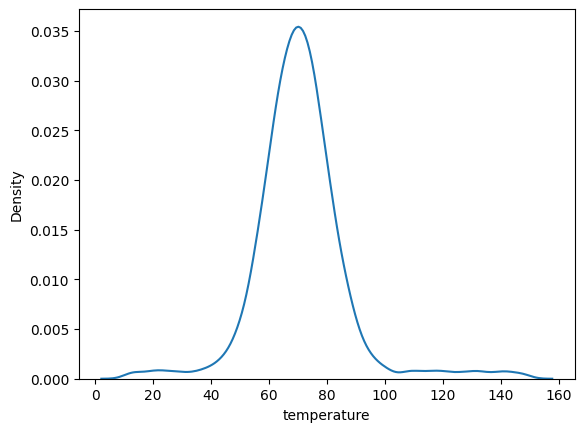

In [22]:
#Density plot of temp
import seaborn as sns
sns.kdeplot(x = 'temperature', data = data)

In [23]:
dummy1 = scaler1.fit_transform(data[['temperature']])

<Axes: ylabel='Density'>

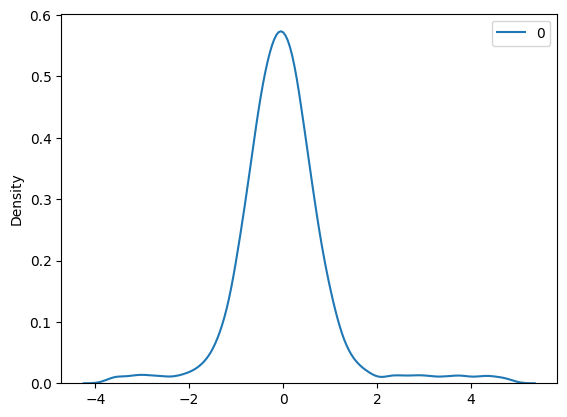

In [24]:
sns.kdeplot(dummy1)

In [25]:
dummy2 = scaler2.fit_transform(data[['temperature']])

<Axes: ylabel='Density'>

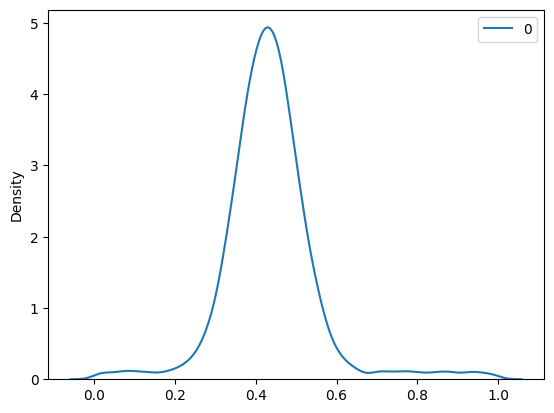

In [26]:
sns.kdeplot(dummy2)

In [27]:
dummy3 = scaler3.fit_transform(data[['temperature']])

<Axes: ylabel='Density'>

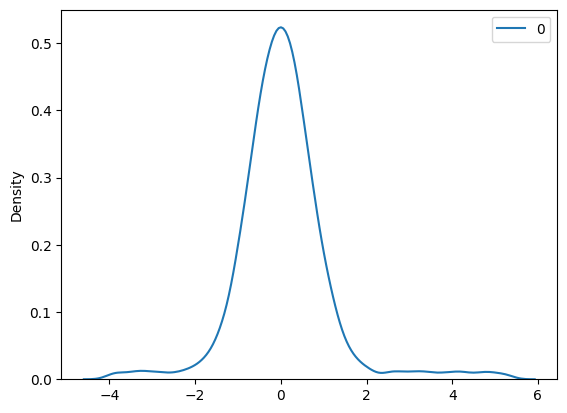

In [28]:
sns.kdeplot(dummy3)
# scaler does not change behaviour it changes the range

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
Y = data['faulty']
X = data.drop('faulty', axis = 1)

In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y , test_size = 0.3, random_state = 42)

In [32]:
X_train.head()

,temperature,pressure,vibration,humidity,equipment,location
5705,65.847862,36.323933,1.541647,55.404568,1,2
3941,70.980675,31.326237,1.554392,49.043959,2,5
3857,80.441609,34.537307,1.983046,59.843625,1,5
4439,68.584704,26.169931,1.100907,40.935039,2,3
5251,62.386447,24.269922,2.614077,24.288631,1,2


In [33]:
X_test.head()

,temperature,pressure,vibration,humidity,equipment,location
6456,119.557732,59.417522,1.685601,62.006769,2,5
3333,80.366324,42.132670,3.893743,27.162418,3,2
5728,65.341944,20.264647,1.093014,70.916654,2,2
5391,86.283966,43.676004,1.697063,52.075283,1,2
1731,62.665179,32.454859,1.035608,61.393884,2,1


In [34]:
Y.unique()

array([0., 1.])

In [35]:
#Logistic regression
from sklearn.linear_model import LogisticRegression

In [36]:
model1 = LogisticRegression()

In [37]:
model1.fit(X_train, Y_train)

LogisticRegression()

In [38]:
#Testing
LR_pred = model1.predict(X_test)

In [39]:
#Accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

print("Accuracy: ", accuracy_score(Y_test, LR_pred))
print("F1_score: ", f1_score(Y_test, LR_pred))
print("Precision: ", precision_score(Y_test, LR_pred))
print("Recall: ", recall_score(Y_test, LR_pred))
print("Confusion Matrix: ", confusion_matrix(Y_test, LR_pred))
print("ROC AUC Score: ", roc_auc_score(Y_test, LR_pred))

Accuracy:  0.9357080799304952
F1_score:  0.5487804878048781
Precision:  0.989010989010989
Recall:  0.379746835443038
Confusion Matrix:  [[2064    1]
 [ 147   90]]
ROC AUC Score:  0.6896312869709137


In [40]:
print("Classification: ", classification_report(Y_test, LR_pred))

Classification:                precision    recall  f1-score   support

         0.0       0.93      1.00      0.97      2065
         1.0       0.99      0.38      0.55       237

    accuracy                           0.94      2302
   macro avg       0.96      0.69      0.76      2302
weighted avg       0.94      0.94      0.92      2302



<Axes: xlabel='faulty', ylabel='count'>

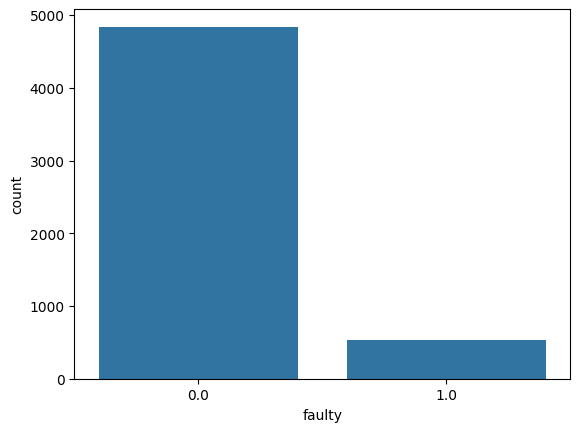

In [41]:
# Make count plot for faulty or not
import seaborn as sns
sns.countplot(x = Y_train)

<Axes: xlabel='faulty', ylabel='count'>

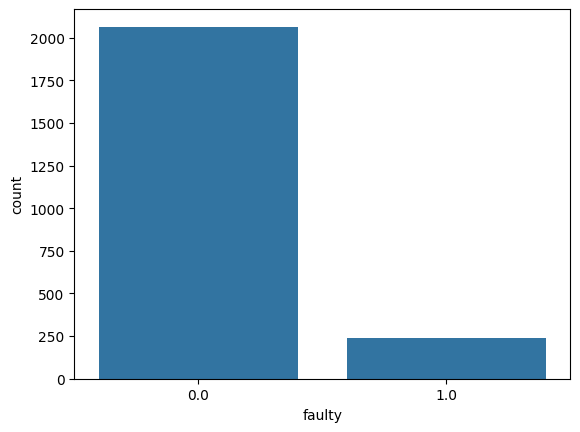

In [42]:
sns.countplot(x = Y_test)

In [43]:
# Support Vector Classifier
# agr classifiation h too svc agr regression h too svr
from sklearn.svm import SVC
model2 = SVC()


In [44]:
model2.fit(X_train, Y_train)

SVC()

In [45]:
svc_pred = model2.predict(X_test)

In [46]:
print("Accuracy: ", accuracy_score(Y_test, svc_pred))
print("F1_score: ", f1_score(Y_test, svc_pred))
print("Precision: ", precision_score(Y_test, svc_pred))
print("Recall: ", recall_score(Y_test, svc_pred))
print("Confusion Matrix: ", confusion_matrix(Y_test, svc_pred))
print("ROC AUC Score: ", roc_auc_score(Y_test, svc_pred))

Accuracy:  0.9739357080799305
F1_score:  0.8578199052132701
Precision:  0.9783783783783784
Recall:  0.7637130801687764
Confusion Matrix:  [[2061    4]
 [  56  181]]
ROC AUC Score:  0.880888017081967


In [47]:
print("Classification: ", classification_report(Y_test, svc_pred))

Classification:                precision    recall  f1-score   support

         0.0       0.97      1.00      0.99      2065
         1.0       0.98      0.76      0.86       237

    accuracy                           0.97      2302
   macro avg       0.98      0.88      0.92      2302
weighted avg       0.97      0.97      0.97      2302



In [48]:
#Decision tree classifier
# dtc when classifier and dtr when regression
# decison tree overift krta h sbse jyada
from sklearn.tree import DecisionTreeClassifier
model3 = DecisionTreeClassifier()

In [49]:
model3.fit(X_train, Y_train)

DecisionTreeClassifier()

In [50]:
dtc_pred = model3.predict(X_test)

In [51]:
print("Accuracy: ", accuracy_score(Y_test, dtc_pred))
print("F1_score: ", f1_score(Y_test, dtc_pred))
print("Precision: ", precision_score(Y_test, dtc_pred))
print("Recall: ", recall_score(Y_test, dtc_pred))
print("Confusion Matrix: ", confusion_matrix(Y_test, dtc_pred))
print("ROC AUC Score: ", roc_auc_score(Y_test, dtc_pred))

Accuracy:  0.9730668983492615
F1_score:  0.8697478991596639
Precision:  0.8661087866108786
Recall:  0.8734177215189873
Confusion Matrix:  [[2033   32]
 [  30  207]]
ROC AUC Score:  0.9289606767401233


In [52]:
print("Classification: ", classification_report(Y_test, dtc_pred))

Classification:                precision    recall  f1-score   support

         0.0       0.99      0.98      0.98      2065
         1.0       0.87      0.87      0.87       237

    accuracy                           0.97      2302
   macro avg       0.93      0.93      0.93      2302
weighted avg       0.97      0.97      0.97      2302



In [53]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
model4 = KNeighborsClassifier()

In [54]:
model4.fit(X_train, Y_train)

KNeighborsClassifier()

In [55]:
knn_pred = model4.predict(X_test)

In [56]:
print("Accuracy: ", accuracy_score(Y_test, knn_pred))
print("F1_score: ", f1_score(Y_test, knn_pred))
print("Precision: ", precision_score(Y_test, knn_pred))
print("Recall: ", recall_score(Y_test, knn_pred))
print("Confusion Matrix: ", confusion_matrix(Y_test, knn_pred))
print("ROC AUC Score: ", roc_auc_score(Y_test, knn_pred))

Accuracy:  0.972632493483927
F1_score:  0.8524590163934426
Precision:  0.9578947368421052
Recall:  0.7679324894514767
Confusion Matrix:  [[2057    8]
 [  55  182]]
ROC AUC Score:  0.8820291987208957


In [57]:
print("Classification: ", classification_report(Y_test, knn_pred))

Classification:                precision    recall  f1-score   support

         0.0       0.97      1.00      0.98      2065
         1.0       0.96      0.77      0.85       237

    accuracy                           0.97      2302
   macro avg       0.97      0.88      0.92      2302
weighted avg       0.97      0.97      0.97      2302



In [58]:
# Naive bayes
from sklearn.naive_bayes import GaussianNB
model5 = GaussianNB()

In [59]:
model5.fit(X_train, Y_train)

GaussianNB()

In [60]:
NB_pred = model5.predict(X_test)

In [61]:
print("Accuracy: ", accuracy_score(Y_test, NB_pred))
print("F1_score: ", f1_score(Y_test, NB_pred))
print("Precision: ", precision_score(Y_test, NB_pred))
print("Recall: ", recall_score(Y_test, NB_pred))
print("Confusion Matrix: ", confusion_matrix(Y_test, NB_pred))
print("ROC AUC Score: ", roc_auc_score(Y_test, NB_pred))

Accuracy:  0.9856646394439618
F1_score:  0.9271523178807947
Precision:  0.9722222222222222
Recall:  0.8860759493670886
Confusion Matrix:  [[2059    6]
 [  27  210]]
ROC AUC Score:  0.9415851901799123


In [62]:
print("Classification: ", classification_report(Y_test, NB_pred))

Classification:                precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      2065
         1.0       0.97      0.89      0.93       237

    accuracy                           0.99      2302
   macro avg       0.98      0.94      0.96      2302
weighted avg       0.99      0.99      0.99      2302



In [63]:
# Random forest classifier
from sklearn.ensemble import RandomForestClassifier
model6 = RandomForestClassifier()

In [64]:
model6.fit(X_train, Y_train)

RandomForestClassifier()

In [65]:
RFC_pred = model6.predict(X_test)

In [66]:
print("Accuracy: ", accuracy_score(Y_test, RFC_pred))
print("F1_score: ", f1_score(Y_test, RFC_pred))
print("Precision: ", precision_score(Y_test, RFC_pred))
print("Recall: ", recall_score(Y_test, RFC_pred))
print("Confusion Matrix: ", confusion_matrix(Y_test, RFC_pred))
print("ROC AUC Score: ", roc_auc_score(Y_test, RFC_pred))

Accuracy:  0.9804517810599479
F1_score:  0.9015317286652079
Precision:  0.9363636363636364
Recall:  0.869198312236287
Confusion Matrix:  [[2051   14]
 [  31  206]]
ROC AUC Score:  0.931209325609669


In [67]:
print("Classification: ", classification_report(Y_test, RFC_pred))

Classification:                precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      2065
         1.0       0.94      0.87      0.90       237

    accuracy                           0.98      2302
   macro avg       0.96      0.93      0.95      2302
weighted avg       0.98      0.98      0.98      2302



In [69]:
# # What is data imbalancing
# K1 =  majority
# K2 = minority
# Upsampling - samples ko equla krna by synthetic samples
# downsampling

# isme use krte h smote